In [428]:
# %pip install torch_geometric
# %pip install ogb
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [429]:
import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

In [430]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull
from torch_geometric.utils import homophily
from torch_geometric.utils import negative_sampling


def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [431]:
# from torch_geometric.datasets import LINKXDataset
# dataset_name = 'Roman-empire'
# dataset = HeterophilousGraphDataset('/tmp/Cora', DATASET_NAME)
# DATASET_NAME = dataset_name
# data = dataset[0]
# print(data)

In [432]:
from torch_geometric.datasets import KarateClub, Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset,LINKXDataset

def load_dataset(dataset_name):
    if dataset_name == "karate":
        dataset = KarateClub()
    elif dataset_name == "moon":
        from ipynb.fs.full.Moon import MoonDataset
        dataset = MoonDataset(n_samples=1000, degree=4, train=0.2, h = 0.2)
    elif dataset_name == "SmallCora":
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')
    elif dataset_name in ["Cora", "Cora_ML" "CiteSeer", "DBLP", "PubMed"]:
        dataset = CitationFull(root=DIR+'/tmp/Citation/'+dataset_name, name=dataset_name)
    elif dataset_name == 'Amazon-ratings':
        dataset = HeterophilousGraphDataset(root=DIR+'/tmp/amazon_ratings', name = dataset_name)
    elif dataset_name == 'Roman-empire':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(DIR+'/tmp/Roman_empire', dataset_name)
    elif dataset_name == "Reddit":
        dataset = Reddit(root=DIR+'/tmp/Reddit')
    elif dataset_name == 'penn94':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(root=DIR+'/tmp/LINKX', name=dataset_name)
    elif dataset_name == 'wiki':
        from torch_geometric.datasets import WikiCS
        dataset = WikiCS(root=DIR+'/tmp/WikiCS')
    elif dataset_name == 'Photo':
        dataset = Amazon(root=DIR+'/tmp/Photo', name='Photo')
    elif dataset_name == 'CiteSeer':
        dataset = Planetoid(root=DIR+'/tmp/CiteSeer', name=DATASET_NAME)
    elif dataset_name == 'CS':
        dataset = Coauthor(root=DIR+'/tmp/CS', name = DATASET_NAME)
    elif dataset_name == 'Physics':
        dataset = Coauthor(root=DIR+'/tmp/Physics', name = DATASET_NAME)
    elif dataset_name == 'Minesweeper':
        dataset   = HeterophilousGraphDataset(root=DIR+'/tmp/Mine',name=dataset_name)
    elif dataset_name == 'pokec':
        print("HELLOWROLD ")
    elif dataset_name == 'ogbn-proteins':
        dataset = PygNodePropPredDataset(name='ogbn-proteins', root=DIR+'/tmp/ogbn-proteins')
        data = dataset[0]
        data.node_species = None
        data.y = data.y.to(torch.float)

        # Initialize features of nodes by aggregating edge features.
        row, col = data.edge_index
        data.x = scatter(data.edge_attr, col, dim_size=data.num_nodes, reduce='sum')
        labels = data.y.argmax(dim=1)
        data.y = labels
        return dataset, data
    elif dataset_name == 'squirrel':
        dataset = WikipediaNetwork(root=DIR+'/tmp/squirrel', name='Squirrel')
    elif dataset_name == 'AmazonProducts':
        dataset = AmazonProducts(root=DIR+'/tmp/AmazonProducts')
    else:
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')

    print(dataset)
    data = dataset[0]
    print(data)
    return dataset, data

# Example usage
dataset_name = "moon"
DATASET_NAME = dataset_name
dataset, data = load_dataset(dataset_name)

MoonDataset(10)
Data(x=[1000, 2], edge_index=[2, 5670], y=[1000], train_mask=[1000], val_mask=[1000], test_mask=[1000], edge_weight=[5670, 1])


In [433]:
# dataset_name = 'Roman-empire'
# DATASET_NAME = dataset_name
# dataset   = HeterophilousGraphDataset(root='/tmp/roman',name=dataset_name)
# print(data)

In [434]:
dataset.num_classes
He = homophily(data.edge_index, data.y, method='edge')
print("Edge Homophily: ", He)

Edge Homophily:  0.32910051941871643


In [435]:
def train_val_test_mask(data, train=0.4, val=0.3, test=0.3, random_state=False):

    if isinstance(data.x, SparseTensor):
        N = data.x.size(0)
        data.num_nodes = N
    else:
        N = data.x.shape[0]

    indexs = list(range(N))

    if random_state:
        train_index, test_index = train_test_split(indexs, test_size=val+test)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test))
    else:
        train_index, test_index = train_test_split(indexs, test_size=val+test, random_state=1)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test), random_state=1)



    train_mask = torch.zeros(N, dtype=bool)
    train_mask[train_index]=True
    val_mask = torch.zeros(N, dtype=bool)
    val_mask[val_index]=True
    test_mask = torch.zeros(N, dtype=bool)
    test_mask[test_index]=True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

In [436]:
if "val_mask" not in data.__dict__['_store']:    
    data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)

if len(data.train_mask.shape) > 1:
    split_index = 2
    data.train_mask = data.train_mask[:,split_index]
    data.val_mask = data.val_mask[:,split_index]
    data.test_mask = data.test_mask[:,split_index]

In [437]:
# Define the MLP for edge probability with dropout
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim, dropout_prob=0.5):
        super(EdgeProbMLP, self).__init__()
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        
        #self.fc1 = nn.Linear(2 * in_channels, hidden_dim) #if straightforward link
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):

        #x = node_features[edge_index[0]]
        #y = node_features[edge_index[1]]
        
        out = F.relu(self.gcn1(node_features, edge_index))
        out = self.dropout(out)
        out = self.gcn2(out, edge_index)
        
        x = out[edge_index[0]]
        y = out[edge_index[1]]
        
        
        edge_features = torch.cat([x,y], dim=1)
        x = F.relu(self.fc1(edge_features))
        x = self.dropout(x)
        prob = torch.sigmoid(self.fc2(x))
        return prob

# Define the overall model with Edge Probabilities and GCNConv (GNN) with dropout
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.5):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [438]:
# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(edge_probs, edge_index, q=500, temperature=1, log=False, istest=False):
        
    if istest:
        samples = F.softmax(edge_probs/temperature, dim=-1)
        top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)
    else:
        print("EP: ",torch.mean(edge_probs).item(), torch.var(edge_probs).item())
        
        samples = F.softmax(edge_probs/temperature, dim=-1)
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
    
        #print(f'{torch.mean(samples).item():.4f}, {torch.var(samples).item():.4f}, {torch.std(samples).item():.4f}')
        print("SP: ",torch.mean(samples).item(), torch.var(samples).item())
        
    print(edge_probs)
    print(samples)

#     gumbels = -torch.empty_like(edge_probs).exponential_().log()
#     gumbels = (gumbels - gumbels.min()) / (gumbels.max() - gumbels.min())
#     gumbels = gumbels/10.0

#     logits = (edge_probs + gumbels) / temperature    
#     samples = F.softmax(logits, dim=-1)

#     top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True) # 50       
#     sampled_edges = torch.multinomial(samples, q, replacement=False)
#     top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)    
    
    one_hot = torch.zeros_like(samples)
    one_hot.scatter_(0, sampled_edges, 1.0)     
    
    indexs = (one_hot - samples).detach() + samples
    
#     if log:
#         print("indexs before: ",indexs)
    
    edge_probs = edge_probs*indexs
    
    indexs = indexs.bool()
    
    
#     if log:        
#         print("edge_probs: ",edge_probs)
# #         print("gumbels: ", gumbels)
# #         print("logits: ",logits)
#         print("samples: ",samples)
#         print("sampled_edges: ",sampled_edges)
#         print("One hot: ", one_hot)
#         print("Indexs: ",indexs)
#         print("edge_probs[indexs]:", edge_probs[indexs])

    
    #return indexs, edge_probs[indexs]
    
#     return indexs, torch.clamp(edge_probs[indexs]+0.5, max=1.0)
    return indexs, edge_probs[indexs]+1e-1
    #return indexs, torch.clamp(edge_probs[indexs]+10, max=1.0)


# Random edge sampling
def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function with alternating updates
def train(epoch, max_epoch, model, optimizer_gnn, optimizer_edge_prob, optimizer, criterion, cluster_loader, device, q=500, mode='learned', alternate_frequency=1):
    model.train()
    total_loss = 0
    iteration = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        
#         if alternate_frequency == 0:
#             update_gnn = True
#             update_edge_prob = True
#         else:            
#             # Decide if we are updating GNN or edge probability model
#             update_gnn = iteration % alternate_frequency == 0
#             update_edge_prob = not update_gnn

#         # Zero gradients selectively
#         if update_gnn:
#             optimizer_gnn.zero_grad()
#         if update_edge_prob:
#             optimizer_edge_prob.zero_grad()

        optimizer.zero_grad()

        # Select edges based on mode
        if mode == 'learned':
            if batch.edge_index.shape[1] > q:
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                #temperature = 2.0 - (epoch * (2 - 0.5) / max_epoch)
                temperature = 1
                #print(temperature)                
                sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q, temperature=temperature, log=(epoch==max_epoch-1))
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]            
                out = model(batch, sampled_edge_index, sampled_edge_weight) 
                #out = model(batch, sampled_edge_index, None)                                        
            else:
                out = model(batch, batch.edge_index)
        elif mode == 'random':
            if batch.edge_index.shape[1] > q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
        elif mode == 'full':
            out = model(batch, batch.edge_index)
        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

        # Compute node classification loss
        loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
        
        if mode == 'learned' and batch.edge_index.shape[1] > q:        
            
            None
    
            #######---regularizer 1
            edge_labels = torch.full((batch.edge_index.size(1),), -1, dtype=torch.long, device=device)
            train_indices = torch.nonzero(batch.train_mask).squeeze()
            train_edge_mask = torch.isin(batch.edge_index[0], train_indices) & torch.isin(batch.edge_index[1], train_indices)

            # Assign labels based on the class of the endpoints
            same_class_mask = batch.y[batch.edge_index[0]] == batch.y[batch.edge_index[1]]
            edge_labels[train_edge_mask & same_class_mask] = 1
            edge_labels[train_edge_mask & ~same_class_mask] = 0

            # Filter out the edges with labels -1
            valid_edge_mask = edge_labels != -1
            valid_edge_probs = edge_probs[valid_edge_mask]
            valid_edge_labels = edge_labels[valid_edge_mask]
            
            #print(torch.sum(valid_edge_labels))
            if torch.sum(valid_edge_labels).item() > 1:            
                loss2 = F.binary_cross_entropy(valid_edge_probs, valid_edge_labels.float().to(device))
            else:
                loss2 = 0
                
            loss = loss+loss2

            
#             ########---regularizer 2

#             train_indices = torch.nonzero(batch.train_mask).squeeze()            
#             num_nodes = train_indices.size(0)
#             num_edges = min(num_nodes*num_nodes,q)  # Adjust the number of edges as needed
#             #num_edges = num_nodes*num_nodes

#             # Generate random edges
#             src = torch.randint(0, num_nodes, (num_edges,))
#             dst = torch.randint(0, num_nodes, (num_edges,))

#             # Map to actual node indices
#             src_nodes = train_indices[src]
#             dst_nodes = train_indices[dst]

#             # Create edge_index tensor
#             reg_edge_index = torch.stack([src_nodes, dst_nodes], dim=0).to(device)
#             reg_edge_label = (batch.y[src_nodes] == batch.y[dst_nodes]).float().to(device)
            
#             reg_edge_probs = model.edge_prob_mlp(batch.x, reg_edge_index).squeeze()
            
#             loss4 = F.binary_cross_entropy(reg_edge_probs, reg_edge_label)

#             #print(reg_edge_index)
#             #print(reg_edge_label)
            
#             loss = loss+loss4
                        
        
        loss.backward()

#         # Update parameters selectively
#         if update_gnn:
#             optimizer_gnn.step()
#         if update_edge_prob:
#             optimizer_edge_prob.step()

        optimizer.step()

        total_loss += loss.item()
        iteration += 1

    return total_loss / len(cluster_loader)

# Evaluation function remains unchanged
def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            if mode == 'learned':
                if batch.edge_index.shape[1] > q:
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                    sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(edge_probs, batch.edge_index, q=q, istest=True)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                    #out = model(batch, sampled_edge_index, None)                                        
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'random':
                if batch.edge_index.shape[1] > q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'full':
                out = model(batch, batch.edge_index)
            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

In [439]:
if "edge_weight" in data.__dict__['_store']:
    print("Edge weights given")
else:
    print("No edge weights")

Edge weights given


In [440]:
data

Data(x=[1000, 2], edge_index=[2, 5670], y=[1000], train_mask=[1000], val_mask=[1000], test_mask=[1000], edge_weight=[5670, 1])

In [441]:
# from sklearn.decomposition import TruncatedSVD

# def adj_feature(data):    
#     adj_mat = torch.zeros((data.num_nodes,data.num_nodes))
#     edges = data.edge_index.t()
#     adj_mat[edges[:,0], edges[:,1]] = 1
#     adj_mat[edges[:,1], edges[:,0]] = 1
    
# #     return adj_mat
    
# #     n_components = data.x.shape[1]
#     n_components = min(256, data.x.shape[1], data.num_nodes)

#     svd = TruncatedSVD(n_components=n_components)
#     x = svd.fit_transform(adj_mat)
    
#     x = torch.Tensor(x)
#     x.shape    
    
#     return x

# data.x = torch.cat((data.x, adj_feature(data)), dim=1)

# # data.x = adj_feature(data)
# # print(data.x.shape)
# # data.x

Main for multiple runs

In [442]:
# data = train_val_test_mask(data, train=0.5, val=0.25, test=0.25)
print(sum(data.train_mask))
data

tensor(200)


Data(x=[1000, 2], edge_index=[2, 5670], y=[1000], train_mask=[1000], val_mask=[1000], test_mask=[1000], edge_weight=[5670, 1])

In [458]:
# Configuration
RUNS = 1
NUM_EPOCHS = 500
best_test_f1s = []
log = True
mode = 'learned'  # available modes ['learned', 'random', 'full']
alternate_frequency = 0
sample_percent = 0.20
figure_log = False

# Check if partitioning is needed
use_metis = data.edge_index.shape[1]>=500000 # or data.num_nodes >= 20000

if use_metis:
    num_edges_per_partition = 500000
    num_parts = int(np.ceil(data.edge_index.shape[1] / num_edges_per_partition))    

#     num_parts = 1500
#     num_edges_per_partition = int(data.edge_index.shape[1] / num_parts)

    sample_size = int(num_edges_per_partition * sample_percent)
    print("Using METIS with num_parts:", num_parts, "avg edges per partition:", num_edges_per_partition, "sample size:", sample_size)
else:
    print("Graph has fewer than 10,000 nodes; don't do graph partition")
    sample_size = int(data.edge_index.shape[1] * sample_percent)

# Partition data using METIS clustering or load the entire graph as a single batch
if use_metis:
    start = time.time()
    cluster_dir = DIR + 'tmp/' + DATASET_NAME
    if not os.path.exists(cluster_dir):
        os.makedirs(cluster_dir)
    
    cluster_data = ClusterData(data, num_parts=num_parts, recursive=False, save_dir=cluster_dir, log=True)
    print("METIS Partition time:", time.time() - start)
    cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)
else:
    cluster_loader = [data]

# Training and evaluation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save_path = 'best_model.pth'

train_figures = []

for run in range(RUNS):
    print("Run:", run)
    
    train_figures = []

    # Initialize model and optimizers
    model = GNNModel(in_channels=data.x.shape[1], hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
    optimizer_gnn = torch.optim.Adam([param for name, param in model.named_parameters() if 'gcn' in name], lr=0.001)
    optimizer_edge_prob = torch.optim.Adam([param for name, param in model.named_parameters() if 'edge_prob_mlp' in name], lr=0.001)    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss()

    # Initialize F1 score trackers
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)
    loss_scores = np.zeros(NUM_EPOCHS)
    
    best_test_f1 = 0
    best_val_f1 = 0

    # Training over epochs
    for epoch in range(NUM_EPOCHS):
        # Alternate training of GNN and edge probability model based on frequency
        loss = train(
            epoch,
            NUM_EPOCHS,
            model,
            optimizer_gnn,
            optimizer_edge_prob,
            optimizer,
            criterion,
            cluster_loader,
            device,
            q=sample_size,
            mode=mode,
            alternate_frequency=alternate_frequency
        )

        # Evaluate model performance on train, validation, and test sets
        train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)

        # Store F1 scores
        train_f1_scores[epoch] = train_f1
        val_f1_scores[epoch] = val_f1
        test_f1_scores[epoch] = test_f1
        loss_scores[epoch] = loss

        # Save model if validation F1 improves
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            #best_test_f1 = test_f1
            torch.save(model.state_dict(), model_save_path)
            if log:
                print(f"*Epoch {epoch}, model saved with Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

#          #Save model if test F1 improves
        if test_f1 > best_test_f1:
            best_test_f1 = test_f1
#             torch.save(model.state_dict(), model_save_path)
#             if log:
#                 print(f"*Epoch {epoch}, model saved with Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

        if log and epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')
            
        if figure_log:
            train_figures.append(visualize(istest=False,show=False))

    # Load the best model for evaluation
    print(f'Best Test F1 throughout: {best_test_f1:.4f}')
    print(f'Loading best model for final evaluation...: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(model_save_path))
    _, _, best_test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
    print(f'Best Test F1 after loading saved model: {best_test_f1:.4f}')
    best_test_f1s.append(best_test_f1)

# Report the mean and standard deviation of the best test F1 scores over runs
print(f'Mean Std of Test F1 Score: {np.mean(best_test_f1s):.4f} +/- {np.std(best_test_f1s):.4f}')

Graph has fewer than 10,000 nodes; don't do graph partition
Run: 0
EP:  0.49475184082984924 0.00017725607904139906
SP:  0.00017636684060562402 5.5167263986188875e-12
tensor([0.4915, 0.5025, 0.4753,  ..., 0.4961, 0.5035, 0.4985], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.4597, 0.4582, 0.4586,  ..., 0.4608, 0.4531, 0.4547], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
*Epoch 0, model saved with Loss: 1.3929, Train F1: 0.5050, Val F1: 0.4667, Test F1: 0.5180
Epoch 0, Loss: 1.3929, Train F1: 0.5050, Val F1: 0.4667, Test F1: 0.5180
EP:  0.4607143700122833 0.00023245046031661332
SP:  0.00017636684060562402 7.218280227011542e-12
tensor([0.4641, 0.4370, 0.4544,  ..., 0.5012, 0.4574, 0.4486], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], devic

EP:  0.3467245399951935 0.0009866738691926003
SP:  0.00017636684060562402 3.05772976383345e-11
tensor([0.3346, 0.3237, 0.3379,  ..., 0.3260, 0.3410, 0.3429], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3533, 0.3396, 0.3466,  ..., 0.3356, 0.3214, 0.3208], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.34402745962142944 0.0009732439648360014
SP:  0.0001763668260537088 3.014143448720752e-11
tensor([0.3679, 0.3369, 0.3201,  ..., 0.3119, 0.2986, 0.3556], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3512, 0.3367, 0.3440,  ..., 0.3320, 0.3183, 0.3175], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.33906954526901245 0.00

tensor([0.3524, 0.3205, 0.3384,  ..., 0.2955, 0.3079, 0.2971], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.3188351094722748 0.0015368512831628323
SP:  0.00017636684060562402 4.775392234424025e-11
tensor([0.3462, 0.3297, 0.3391,  ..., 0.2661, 0.2449, 0.2734], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3552, 0.3222, 0.3409,  ..., 0.2958, 0.3103, 0.2989], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.32445967197418213 0.001604566932655871
SP:  0.00017636684060562402 4.9874330360077934e-11
tensor([0.3594, 0.2835, 0.3641,  ..., 0.3232, 0.3548, 0.2781], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3552, 0.3210, 0.3

tensor([0.3667, 0.2987, 0.3388,  ..., 0.2377, 0.3002, 0.2682], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.2931254506111145 0.0030113188549876213
SP:  0.0001763668260537088 9.417008145495842e-11
tensor([0.3976, 0.3673, 0.3798,  ..., 0.2842, 0.3639, 0.2426], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3693, 0.2995, 0.3407,  ..., 0.2365, 0.3020, 0.2688], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.29249104857444763 0.003079846501350403
SP:  0.0001763668260537088 9.670721862198306e-11
tensor([0.4185, 0.3268, 0.3521,  ..., 0.2359, 0.2778, 0.1831], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3815, 0.3096, 0.3522

tensor([0.4278, 0.3138, 0.3824,  ..., 0.2201, 0.3400, 0.2796], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.30189278721809387 0.0052371155470609665
SP:  0.00017636684060562402 1.6625155419003335e-10
tensor([0.4308, 0.3218, 0.3895,  ..., 0.1997, 0.2746, 0.2480], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.4116, 0.2970, 0.3653,  ..., 0.2079, 0.3204, 0.2624], device='cuda:0')
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.2938687205314636 0.005400862544775009
SP:  0.0001763668260537088 1.726236098509304e-10
tensor([0.3384, 0.2546, 0.3354,  ..., 0.1787, 0.3349, 0.3149], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.3910, 0.2785, 0.34

...

tensor([0.7612, 0.1267, 0.4909,  ..., 0.2433, 0.3368, 0.1775], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.2940921485424042 0.031346116214990616
SP:  0.00017636684060562402 1.3388871122899104e-09
tensor([0.5779, 0.2022, 0.7726,  ..., 0.1902, 0.2759, 0.1410], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0002, 0.0003,  ..., 0.0002, 0.0002, 0.0001], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7611, 0.1266, 0.4917,  ..., 0.2434, 0.3382, 0.1786], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.29575467109680176 0.03218093886971474
SP:  0.00017636684060562402 1.3684056110463416e-09
tensor([0.8898, 0.1311, 0.3943,  ..., 0.2280, 0.5032, 0.1771], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7684, 0.1284, 0.50

tensor([0.7642, 0.1198, 0.4957,  ..., 0.2475, 0.3319, 0.1790], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.28839021921157837 0.03349805250763893
SP:  0.0001763668260537088 1.4541980952742506e-09
tensor([0.7452, 0.1162, 0.3653,  ..., 0.1403, 0.2019, 0.1329], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0001, 0.0002, 0.0001], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7863, 0.1223, 0.5281,  ..., 0.2479, 0.3663, 0.1804], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.29629337787628174 0.035164233297109604
SP:  0.0001763668260537088 1.517827086239265e-09
tensor([0.7131, 0.0646, 0.6622,  ..., 0.2390, 0.1813, 0.1336], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0001], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.8094, 0.1290, 0.5644

EP:  0.30389851331710815 0.03696368634700775
SP:  0.0001763668260537088 1.5589946000815758e-09
tensor([0.8250, 0.0565, 0.6178,  ..., 0.3021, 0.2967, 0.2057], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7966, 0.1208, 0.5205,  ..., 0.2576, 0.3548, 0.1855], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.3039746582508087 0.03737129271030426
SP:  0.00017636684060562402 1.5899438432498414e-09
tensor([0.7896, 0.1588, 0.4273,  ..., 0.1804, 0.2816, 0.1658], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7768, 0.1155, 0.4873,  ..., 0.2571, 0.3190, 0.1834], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.28391435742378235 0.031

tensor([0.7435, 0.1039, 0.4207,  ..., 0.2494, 0.2542, 0.1890], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.26585257053375244 0.028975175693631172
SP:  0.00017636685515753925 1.2754790557067963e-09
tensor([0.5375, 0.0616, 0.5092,  ..., 0.2591, 0.3379, 0.1394], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0002, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7949, 0.1055, 0.4959,  ..., 0.2500, 0.3268, 0.1910], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.29757821559906006 0.03842544183135033
SP:  0.0001763668260537088 1.6610091080337952e-09
tensor([0.9383, 0.2049, 0.5062,  ..., 0.4148, 0.4124, 0.2140], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.8321, 0.1092, 0.55

EP:  0.27471017837524414 0.03339191526174545
SP:  0.00017636684060562402 1.4567491657402343e-09
tensor([0.7854, 0.1207, 0.2942,  ..., 0.3235, 0.1548, 0.2216], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7522, 0.0905, 0.4227,  ..., 0.2737, 0.2478, 0.1820], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.2764589488506317 0.03365952521562576
SP:  0.0001763668260537088 1.4464603959041256e-09
tensor([0.9205, 0.0469, 0.4372,  ..., 0.2575, 0.1476, 0.2257], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0.7509, 0.0908, 0.4225,  ..., 0.2773, 0.2473, 0.1816], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
EP:  0.27374812960624695 0.033

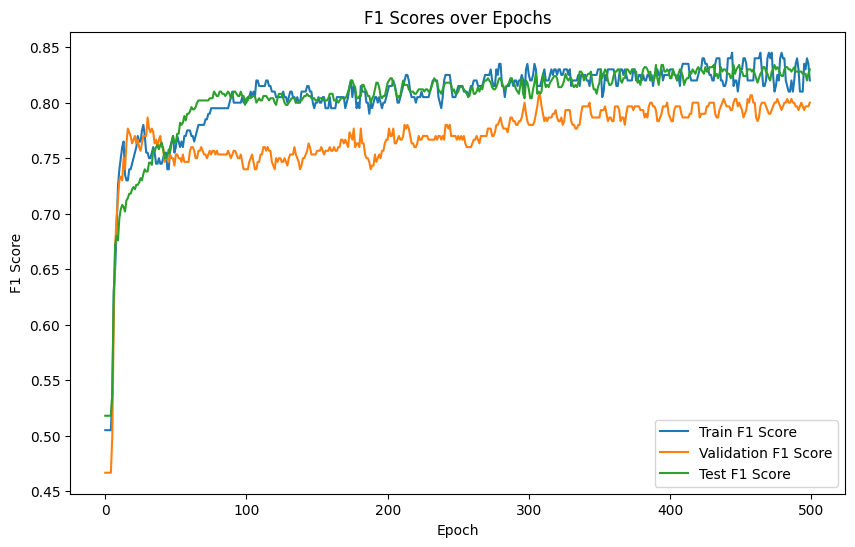

In [459]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
# plt.plot(loss_scores, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [460]:
for batch in cluster_loader:
    print(batch.num_nodes)
    print(batch.edge_index.shape)

1000
torch.Size([2, 5670])


In [461]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

In [462]:
torch.where(data.train_mask == True)

(tensor([  1,  16,  18,  24,  26,  28,  33,  34,  38,  49,  50,  53,  56,  66,
          76,  85,  88,  92, 113, 129, 136, 149, 150, 157, 174, 177, 178, 184,
         185, 188, 189, 195, 198, 200, 202, 210, 211, 221, 229, 241, 247, 251,
         256, 264, 282, 287, 290, 293, 298, 299, 308, 311, 316, 325, 327, 330,
         334, 336, 342, 349, 350, 354, 355, 359, 361, 364, 365, 369, 374, 375,
         381, 386, 392, 393, 396, 398, 401, 414, 417, 418, 424, 426, 428, 436,
         450, 451, 461, 463, 466, 467, 474, 475, 476, 483, 489, 490, 493, 496,
         499, 501, 506, 507, 508, 515, 516, 522, 523, 527, 528, 538, 554, 560,
         577, 581, 585, 586, 589, 594, 596, 606, 607, 612, 614, 615, 617, 622,
         630, 631, 637, 638, 653, 660, 666, 668, 670, 680, 682, 688, 693, 694,
         697, 702, 713, 720, 727, 731, 732, 740, 741, 744, 750, 760, 763, 765,
         769, 770, 772, 776, 788, 789, 790, 792, 797, 799, 807, 809, 816, 819,
         823, 836, 842, 848, 850, 864, 877, 879, 891

In [463]:
def count_edges_with_different_labels(data, sampled_edge_index):
    """
    Counts edges with different labels at endpoints in both the original and sampled graphs.
    
    Args:
        data: Data object containing the original graph information.
        sampled_edge_index: Edge index of the sampled subgraph.
    
    Returns:
        A dictionary with counts and percentages of edges with different labels.
    """
    # Original graph edges
    original_edges = data.edge_index
    num_original_edges = original_edges.size(1)
    
    # Count edges with different labels in the original graph
    different_label_edges_original = 0
    for i in range(num_original_edges):
        node1, node2 = original_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_original += 1
    
    # Sampled graph edges
    sampled_edges = sampled_edge_index
    num_sampled_edges = sampled_edges.size(1)

    # Count edges with different labels in the sampled graph
    different_label_edges_sampled = 0
    for i in range(num_sampled_edges):
        node1, node2 = sampled_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_sampled += 1

    # Calculate percentages
    percentage_original = (different_label_edges_original / num_original_edges) * 100 if num_original_edges > 0 else 0
    percentage_sampled = (different_label_edges_sampled / num_sampled_edges) * 100 if num_sampled_edges > 0 else 0

    # Prepare the result
    result = {
        "original_graph": {
            "different_label_edges": different_label_edges_original,
            "total_edges": num_original_edges,
            "percentage": percentage_original
        },
        "sampled_graph": {
            "different_label_edges": different_label_edges_sampled,
            "total_edges": num_sampled_edges,
            "percentage": percentage_sampled
        }
    }

    return result

In [464]:
def plot_full_graph_with_train_nodes(data, train_mask, ax=None):
    """
    Plots the full graph with training nodes highlighted and colored by their labels.
    Args:
        data: Data object containing edge_index, node labels, and other features.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert PyG data to NetworkX graph for visualization
    G = to_networkx(data)
    
    # Generate color map for each label
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Set node colors based on whether they are a training node and their label
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() else 'gray' for i in range(data.num_nodes)
    ]
    
    pos = None
    
    if DATASET_NAME == 'moon':
        pos = {i: (data.x[i][0].item(), data.x[i][1].item()) for i in range(len(data.x))}
    elif pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Plot the full graph with training nodes highlighted by label color
    nx.draw(G, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="lightblue")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Full Graph with Training Nodes Highlighted by Label")
    ax.axis("off")
    
    return pos


def plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=None, pos=None):
    """
    Plots the sampled subgraph based on the edge probability model with training nodes highlighted by label.
    Args:
        data: Data object containing node information.
        sampled_edge_index: Edge index of the sampled subgraph.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert sampled edges to NetworkX graph
    G_sampled = to_networkx(Data(x = data.x, y = data.y, edge_index = sampled_edge_index))
    
    # Use same color map as the full graph
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Use same layout as the full graph for consistent positioning
    if pos is None:
        pos = nx.spring_layout(G_sampled, seed=42)
    
    # Set node colors based on training status and label for nodes in the sampled graph
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() and i in G_sampled.nodes else 'gray'
        for i in G_sampled.nodes
    ]

    # Plot the sampled subgraph with node labels
    nx.draw(G_sampled, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="orange")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Sampled Subgraph (Edge Probability Model) with Training Nodes Highlighted by Label")
    ax.axis("off")


def visualize_graphs_side_by_side(data, train_mask, sampled_edge_index, show=True):
    """
    Visualizes the full graph with training nodes and the sampled subgraph side by side, with training nodes colored by label.
    Args:
        data: Data object containing the full graph information.
        train_mask: Boolean tensor indicating training nodes.
        sampled_edge_index: Edge index of the sampled subgraph.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot full graph with training nodes highlighted by label
    pos1 = plot_full_graph_with_train_nodes(data, train_mask, ax=ax1)

    # Plot sampled subgraph with training nodes highlighted by label, using the same layout
    plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=ax2, pos=pos1)
    
    if show==False:
        plt.close()
    else:
        plt.show()
    
    return fig

# Example Usage:
# Assuming `train_mask` is a boolean mask tensor, and `sampled_edge_index` is the edge index after sampling
# visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index)

In [465]:
def visualize(istest=True, show=True):
    if use_metis == False:
        with torch.no_grad():
            edge_probs = model.edge_prob_mlp(data.x, data.edge_index).squeeze()
            sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(
                edge_probs,
                data.edge_index,
                q=sample_size, istest=istest)

            sampled_edge_index = data.edge_index[:, sampled_edge_indices]
            fig = None
            #fig = visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index, show=show)

            # Example Usage
            # Assuming `data` is your original graph and `sampled_edge_index` is your sampled edge index
            result = count_edges_with_different_labels(data, sampled_edge_index)

            print("\% of heterophily:")

            # Print the results
            print(f"Original graph: {result['original_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['original_graph']['total_edges']} total edges "
                  f"({result['original_graph']['percentage']:.2f}%).")

            print(f"Sampled graph: {result['sampled_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['sampled_graph']['total_edges']} total edges "
                  f"({result['sampled_graph']['percentage']:.2f}%).")
            
            return fig
            
fig = visualize(False) #Sampled from the best
fig = visualize(True)  #Best Sparsifier

EP:  0.25430557131767273 0.022501608356833458
SP:  0.00017636684060562402 9.775557030522464e-10
tensor([0.7033, 0.1045, 0.3703,  ..., 0.2525, 0.2125, 0.1887], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
\% of heterophily:
Original graph: 3804 edges with different labels out of 5670 total edges (67.09%).
Sampled graph: 756 edges with different labels out of 1134 total edges (66.67%).
tensor([0.7033, 0.1045, 0.3703,  ..., 0.2525, 0.2125, 0.1887], device='cuda:0')
tensor([0.0003, 0.0001, 0.0002,  ..., 0.0002, 0.0002, 0.0002], device='cuda:0')
\% of heterophily:
Original graph: 3804 edges with different labels out of 5670 total edges (67.09%).
Sampled graph: 649 edges with different labels out of 1134 total edges (57.23%).


In [451]:
# def sample_gumbel(shape, eps=1e-20):
#     """Sample from Gumbel(0, 1)"""
#     U = torch.rand(shape)
#     return -torch.log(-torch.log(U + eps) + eps)

# # Example usage
# shape = (10,)  # Sample 10 values
# gumbel_noise = sample_gumbel(shape)
# print(gumbel_noise)

## Animate the Sparsification

In [452]:
def store_figures_during_test():
    figures = []
    for epoch in range(20):  # Assuming 100 epochs
        fig = visualize(False, False)
        figures.append(fig)
        plt.close(fig)
    return figures

# figures = store_figures_during_test()

In [453]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation_from_figures(figures):
    fig_anim, ax_anim = plt.subplots()

    def update_fig(i):
        ax_anim.clear()
        figures[i].canvas.draw()
        img_array = np.frombuffer(figures[i].canvas.tostring_rgb(), dtype=np.uint8)
        img_array = img_array.reshape(figures[i].canvas.get_width_height()[::-1] + (3,))
        ax_anim.imshow(img_array)
        ax_anim.axis('off')

    ani = animation.FuncAnimation(fig_anim, update_fig, frames=len(figures), interval=200, blit=False)

    from IPython.display import HTML
    return HTML(ani.to_jshtml())

# # Example Usage:
# # Assuming `figures` is a list of stored figure objects from `store_figures_during_training`.
# animation_html = create_animation_from_figures(figures)
# display(animation_html)

In [454]:
if figure_log:
    animation_html = create_animation_from_figures(train_figures)
    display(animation_html)